# Técnicas e Instrumentación en Psicofisiología
Elaborado por el Mtro. Angel Jacobo para la Facultad de Medicina y Psicología, Universidad Autónoma de Baja California.

# Práctica 5: Procesamiento de Bioseñales, Electroencefalograma (EEG)



##Funciones de apoyo
Ejecute estas celdas para preparar algunas características del ambiente que serán necesarias para la práctica

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 47.9 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [2]:
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets import eegbci
subjects = [1]  # may vary
runs = [3]  # may vary
raw_fnames = eegbci.load_data(subjects, runs)
raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
# concatenate runs from subject
raw = concatenate_raws(raws)
# make channel names follow standard conventions
eegbci.standardize(raw)


datos=[]
eventos=[[],[],[]]
for i in range(64):
    datos.append((raw[0][1][0:], raw[i][0][0][0:]))
for i in range(len(raw.annotations)):
  if raw.annotations[i]['description'] == 'T0':
    eventos[0].append(raw.annotations[i]['onset'])
  if raw.annotations[i]['description'] == 'T1':
    eventos[1].append(raw.annotations[i]['onset'])
  if raw.annotations[i]['description'] == 'T2':
    eventos[2].append(raw.annotations[i]['onset'])

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m37s (2.5 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


## Sección 2. Transformaciones y Análisis Espectral

Durante la primera parte, exploró un método de análisis para la identificación de Potenciales Relacionados a Eventos. Esta vez, estudiaremos la descomposición de la señal de electroencefalograma con la que hemos estado trabajando.

Recuerde que una señal de potencial eléctrico es la suma de todos los potenciales detectados en la cercanía de un electrodo. Puede imaginarlo como un proceso similar a la manera en que un micrófono captura todos los sonidos que ocurren a su alrededor. Sin embargo, a menudo es necesario poder extraer la información individual que compone a esa señal "mezclada." Es en esos casos cuando hemos de recurrir al análisis espectral.

El análisis espectral puede entenderse como el conjunto de técnicas de análisis de señales que se basa en la descomposición espectral: una familia de transformaciones que convierten la representación del dominio del tiempo de una señal a una representación del dominio de la frecuencia.

#### Ejemplo 2.1

---

Para llevar a cabo las transformaciones necesarias, nos valdremos nuevamente de la biblioteca Numpy, que cuenta con un módulo para la Transformada de Fourier Discreta.

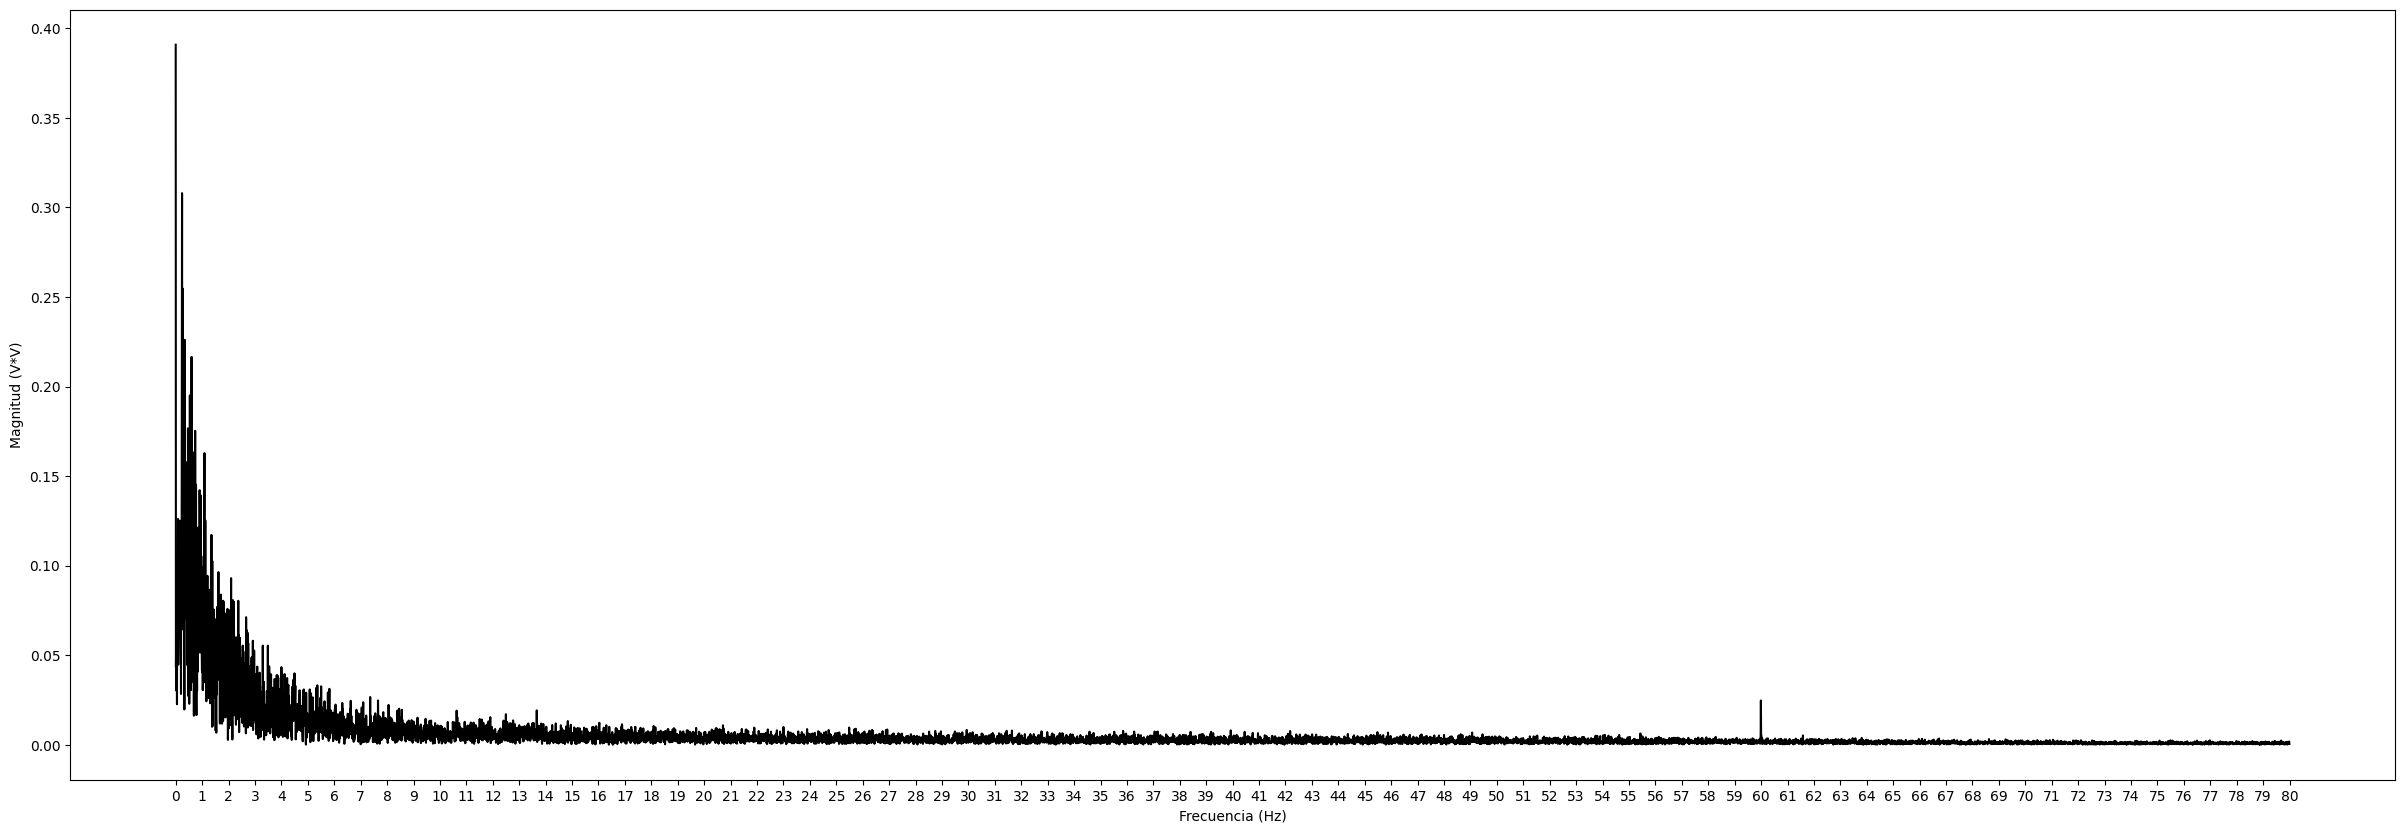

In [70]:
import matplotlib.pyplot as plt
import numpy as np

electrodo = 26

k = electrodo - 1
frec_muestreo = 160
fourier = np.fft.fft(datos[k][1])
freqs = np.fft.fftfreq(len(datos[k][1]), 1/frec_muestreo)

plt.figure(figsize=(30,10))
plt.axes(xlabel= "Frecuencia (Hz)" , ylabel= "Magnitud (V*V)")
plt.xticks(range(81))
plt.plot(freqs[:10000], np.abs(fourier[0:10000]), color = '0')

Note que es necesario computar por separado las frecuencias que representan a las ondas que componen a nuestra señal.

#### Ejercicio 2.1

---

Estudie el ejemplo, después grafique dos electrodos frontales anteriores (AF) y dos electrodos occipitales (O). Conteste lo que se pide

In [ ]:
#Aquí grafique un electrodo frontal

In [ ]:
#Aquí grafique un electrodo frontal

In [ ]:
#Aquí grafique un electrodo occipital

In [ ]:
#Aquí grafique un electrodo occipital

2.1.1 Responda: ¿Qué diferencias de magnitud total nota entre los dos grupos de electrodos?

In [ ]:
#

2.1.2 Responda: ¿Qué diferencias nota en términos de la distribución de potencia de las frecuencias? (Por ejemplo, qué frecuencias muestran mayor magnitud en un grupo de electrodos)

In [ ]:
#

2.1.3 Responda: Parece observarse un artefacto en las señales. ¿Qué frecuencia tiene, y de dónde podría proceder?

In [ ]:
#

#### Ejercicio 2.2 (Opcional)

---
Utilice los resultados del cálculo de promedios de ventanas de reposo o actividad de la primera parte de esta práctica, y realice una transformada de Fourier para obtener información de los ritmos neuronales involucrados durante cada condición.


In [ ]:
# Tendrá que modificar el cálculo de la transformada y las frecuencias para
# ajustarse al tamaño de las ventanas que diseñamos antes

# Por ejemplo:

fourier = np.fft.fft(mi_señal_promedio])
freqs = np.fft.fftfreq(len(mi_señal_promedio), 1/frec_muestreo)

#Podemos dejar la frecuencia de muestreo igual.


2.2.2 Responda: ¿Qué diferencias nota en la distribución de la potencia de las frecuencias?"

In [ ]:
#